# Problem Statement:
Obesity is a major public health concern influenced by multiple factors, including diet and physical activity. This study aims to estimate obesity levels based on individuals’ eating habits and physical condition. The goal is to identify patterns and associations that can help predict which individuals are at higher risk of obesity, enabling targeted interventions and promoting healthier lifestyles.

In [44]:
# # import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from scipy import stats
from scipy.stats import randint
import random

In [3]:
import os
import chardet

file_path = os.path.join(r"C:\Users\Harish5.B\OneDrive - Reliance Corporate IT Park Limited\Desktop\Career Improvement\Projects\EDA\obesity.csv")
raw_data = open(file_path,'rb').readline()

encoding = chardet.detect(raw_data)
print("file encoding details:\n",encoding)

file encoding details:
 {'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


The default encoding detected is "ascii" with 100% confidence level. Hence we can proceed.

In [4]:
#Read 'obesity.csv' file
file_paths = (r"C:\Users\Harish5.B\OneDrive - Reliance Corporate IT Park Limited\Desktop\Career Improvement\Projects\EDA\obesity.csv")
df = pd.read_csv(file_paths, low_memory =False)

pd.set_option('display.max_rows',1000)
pd.set_option('display.max_columns',1000)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
##stripping off white spaces from the columnname (if any)

df_obese = df.rename(columns = lambda x : x.strip(), inplace = False)

In [6]:
##define shape of the dataframe

df_obese.shape

(2111, 17)

In [7]:
##total data available at start
total_data_before = df_obese.shape[0]
print("total_records (at the start):",total_data_before )

total_records (at the start): 2111


# Data Cleaning and Manipulation

There are in total 2111 rows and 17 columns in the dataset.so creating a function to drop columns that have NaN Values over a 
threshold makes sense

In [8]:
##creating a function to eliminate columns having more than 50 % missing values

def dropnacolumns(df,val =1,percent =50):
    
    '''
    df is the dataframe that needs to be manipulated
    val :val = 0 represents drop rows , val =1 represents drop column (default value is 1 for column manipulation)
    percent is the total percentage value that will be used as threshold to see how much % of NaN values are there in the column
    '''
    df_newp = df.copy()
    
    if val ==1:
        columns_NA_percent = 100 *df_newp.isnull().sum()/len(df_newp.index)
        list_NA_columns = list(columns_NA_percent[(columns_NA_percent > percent)].index)
        df_newp.drop(list_NA_columns, axis=1, inplace =True)
        print("Total number dropped columns (with more than 50% of missing values):",len(list_NA_columns))
        print("\nDropped column names are as follows:",list_NA_columns)
    else:
        rows_NA_percent  = 100 *df_newp.isnull().sum(axis=1)/len(df_newp.index)
        list_NA_rows = list(rows_NA_percent[(rows_NA_percent > percent)].index)
        df_newp.drop(list_NA_rows, axis=0, inplace =True)
        print("Total number dropped rows (with more than 50 % of missing values):",len(list_NA_rows))
        print("\nDropped rows names are as follows:", list_NA_rows)
        
    return df_newp

In [9]:
##retaining the columns with <=50% missing values

df_obese = dropnacolumns(df_obese,val=1,percent=50)

Total number dropped columns (with more than 50% of missing values): 0

Dropped column names are as follows: []


In [10]:
##retaining the columns with <=50% missing values

df_obese = dropnacolumns(df_obese,val=0,percent=50)

Total number dropped rows (with more than 50 % of missing values): 0

Dropped rows names are as follows: []


In [11]:
df_obese.shape

(2111, 17)

In [12]:
df_obese.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [13]:
def remove_single_val_uniq_col(df):
    df_newsingle = df.copy()
    
    uniq_svcol = df_newsingle.nunique()==1
    list_uniq_svcol = list(uniq_svcol[uniq_svcol.values == True].index)
    df_newsingle.drop(list_uniq_svcol,axis=1,inplace=True)
    return df_newsingle

In [14]:
df_obese = remove_single_val_uniq_col(df_obese)
df_obese.shape

(2111, 17)

In [15]:
##Removing duplicates(if any)
df_obese = df_obese.drop_duplicates()
df_obese.shape

(2087, 17)

In [16]:
df_obese.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [17]:
missng_val_percent = round(100 * df_obese.isnull().sum()/len(df_obese.index),4)
missng_val_percent[missng_val_percent!= 0]

Series([], dtype: float64)

# Univariate Analysis & Segment Analysis 

In [18]:
##list of Numerical columns
#df_numeric = df_obese.select_dtypes(include = np.number)
num_cols = [ col for col in df_obese.columns if df_obese[col].dtype == np.number]
print(num_cols)

df_num = df_obese[num_cols]
df_num

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


C:\Users\Harish5.B\AppData\Local\Temp\ipykernel_32532\501619120.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  num_cols = [ col for col in df_obese.columns if df_obese[col].dtype == np.number]


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.000000,1.620000,64.000000,2.0,3.0,2.000000,0.000000,1.000000
1,21.000000,1.520000,56.000000,3.0,3.0,3.000000,3.000000,0.000000
2,23.000000,1.800000,77.000000,2.0,3.0,2.000000,2.000000,1.000000
3,27.000000,1.800000,87.000000,3.0,3.0,2.000000,2.000000,0.000000
4,22.000000,1.780000,89.800000,2.0,1.0,2.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,3.0,3.0,1.728139,1.676269,0.906247
2107,21.982942,1.748584,133.742943,3.0,3.0,2.005130,1.341390,0.599270
2108,22.524036,1.752206,133.689352,3.0,3.0,2.054193,1.414209,0.646288
2109,24.361936,1.739450,133.346641,3.0,3.0,2.852339,1.139107,0.586035


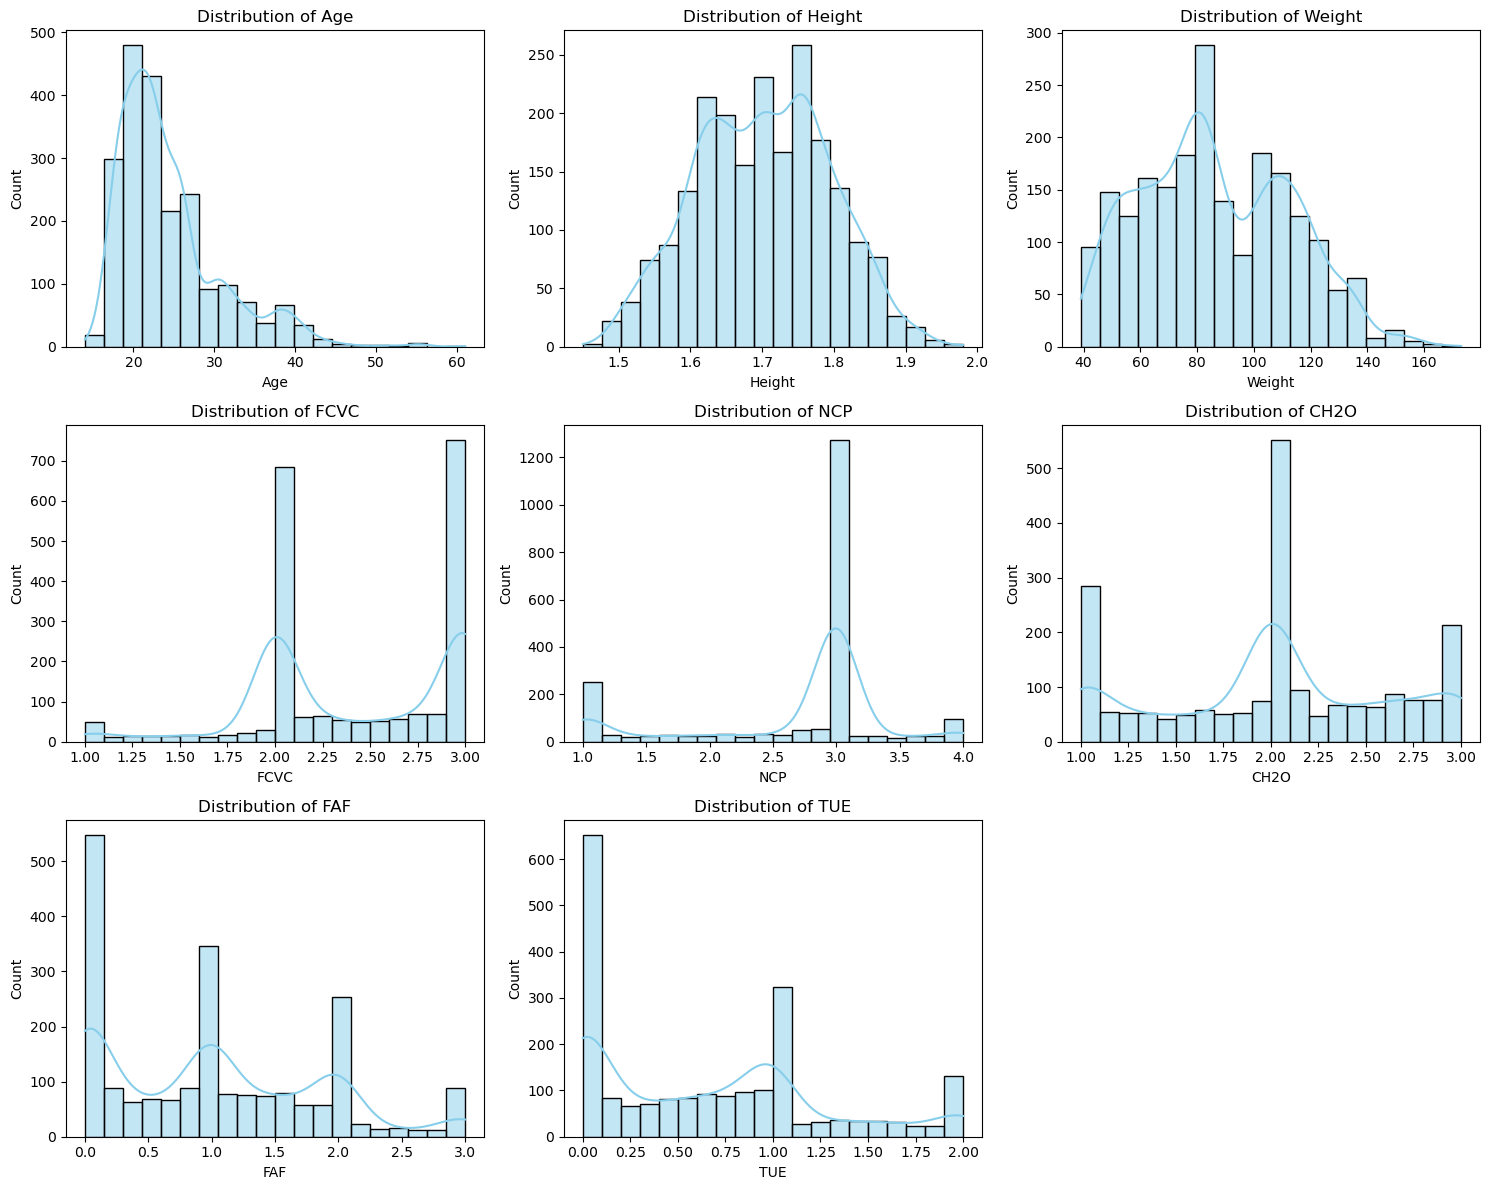

In [19]:
##Histogram for Numerical Features

numerical_params = df_num

plt.figure(figsize=(15,12))
for i, col in enumerate(numerical_params):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde =True, bins =20, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [20]:
#categorical_data
cat_cols = [col for col in df_obese.columns if df_obese[col].dtype == 'object']
print(cat_cols)

df_cat = df_obese[cat_cols]
df_cat

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...
2106,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III


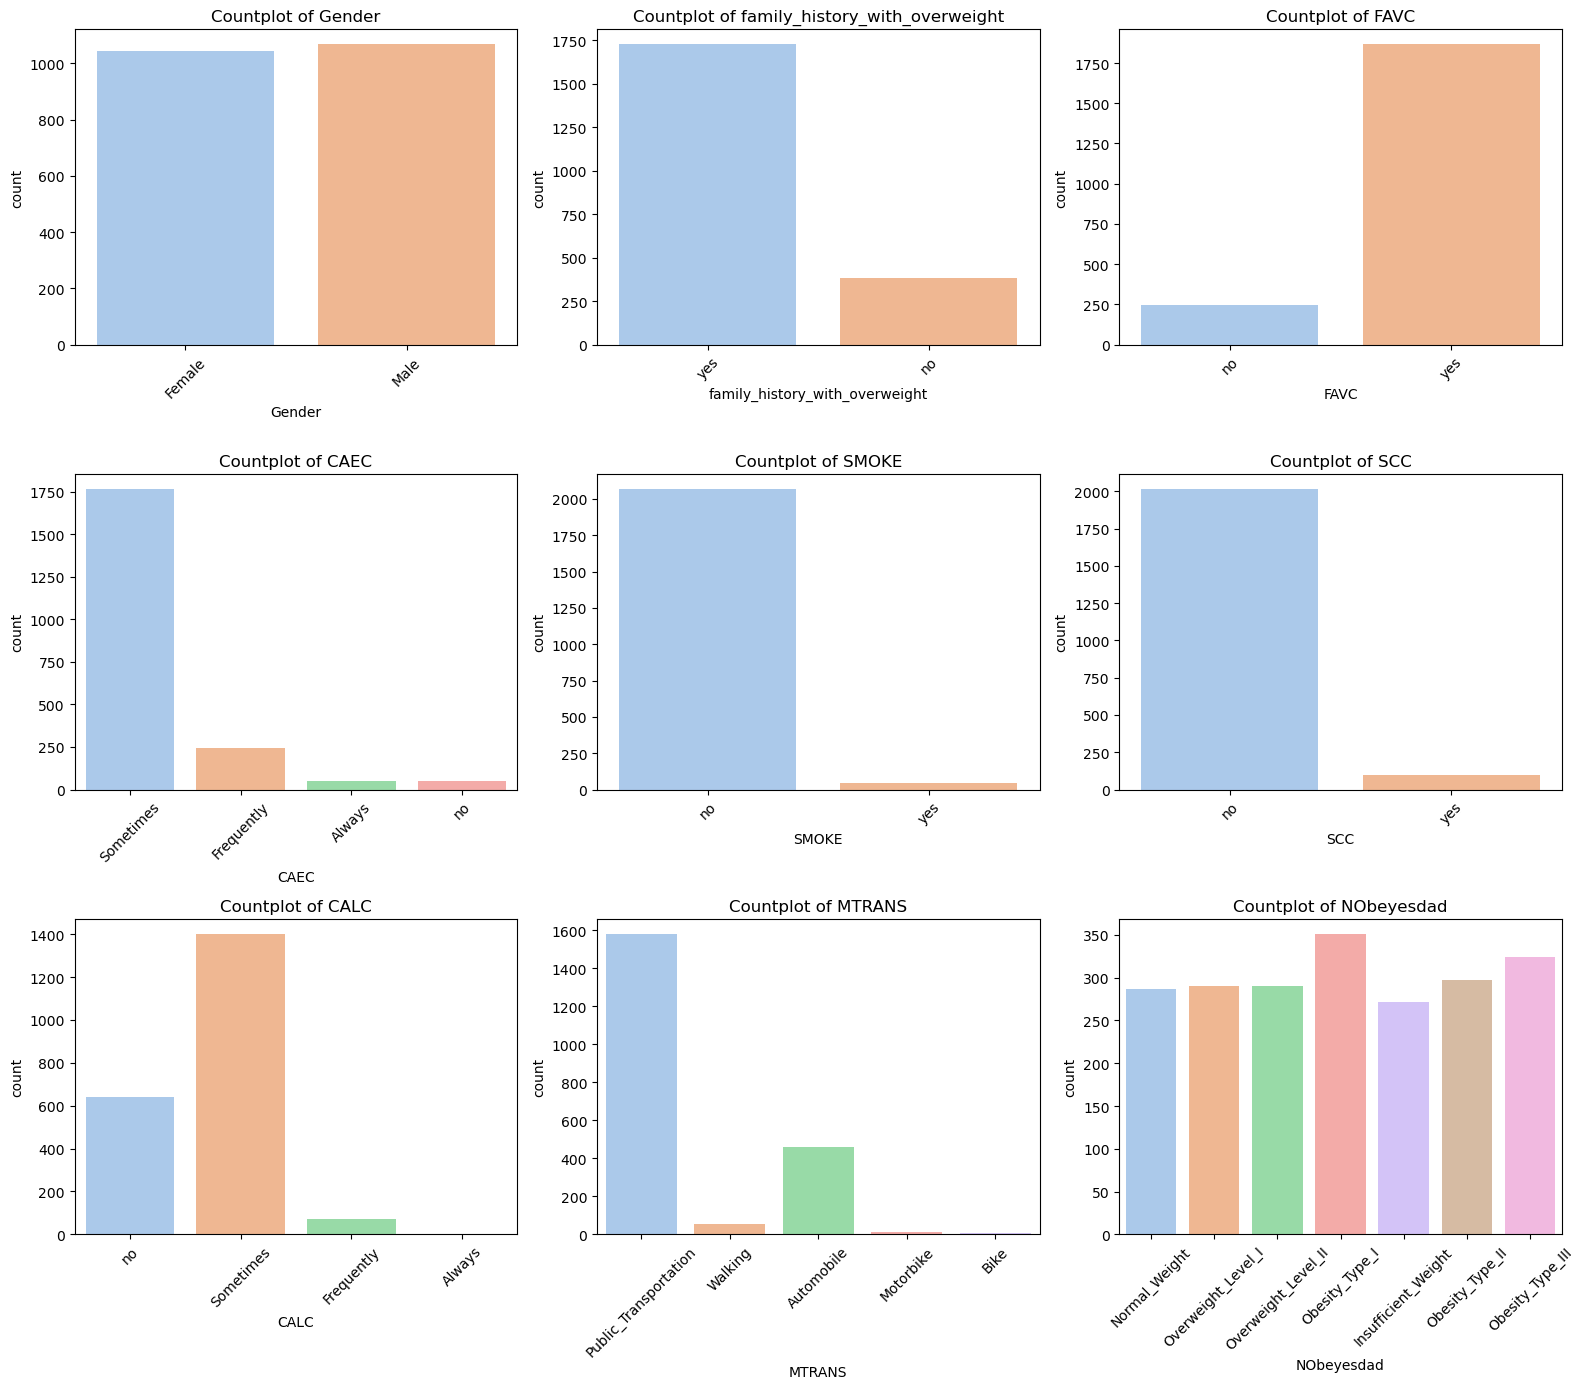

In [21]:
categorical_features = df_cat

plt.figure(figsize=(16, 14))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
## What percentage of smokers fall into higher obesity categories?
df_cat['SMOKE'].value_counts()

no     2043
yes      44
Name: SMOKE, dtype: int64

In [23]:
df_cat['NObeyesdad'].value_counts()

Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: NObeyesdad, dtype: int64

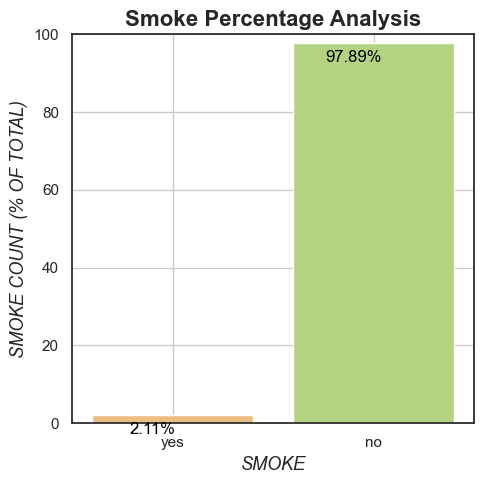

In [24]:
#Lets check Smoker percent in Visualisation
sns.set(style='white')
plt.figure(figsize=(5,5), dpi=100)

br = pd.DataFrame(df_cat['SMOKE'].value_counts(normalize=True).mul(100).sort_values())
br.reset_index(inplace=True)
br = br.rename(columns={'index': 'SMOKE', 'SMOKE': 'SMOKE_COUNT'})

ax = sns.barplot(x='SMOKE', y='SMOKE_COUNT', data=br, palette='RdYlGn')

plt.xlabel('SMOKE', fontsize=13, fontstyle='italic')
plt.ylabel('SMOKE COUNT (% OF TOTAL)', fontsize=13, fontstyle='italic')
plt.title('Smoke Percentage Analysis', fontsize=16, fontweight='bold')
plt.ylim(0, 100)

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2.0 - 0.1, i.get_height() - 5,
            f"{round(i.get_height(), 2)}%",
            ha='center', fontsize=12, color='black')

plt.grid(True)
plt.tight_layout()
plt.show()


Observation :That’s >97% "no". This is a highly imbalanced categorical variable.

 The Percentage of Smokers who are highly obesed is: 61.36363636363637


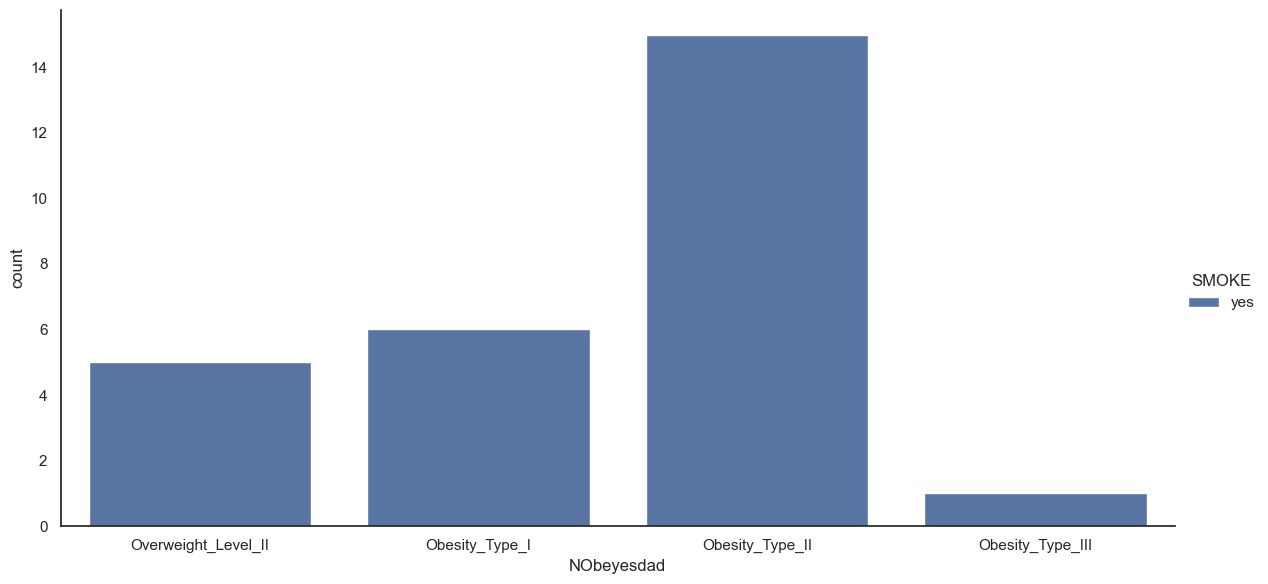

In [25]:
# we can still think of use like What percentage of smokers fall into higher obesity categories?
df_smokers = df_cat[df_cat['SMOKE']=='yes']

higher_obese_category = ['Overweight_Level_II', 
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III']

smokers_in_higher_obesity = df_smokers[df_smokers['NObeyesdad'].isin(higher_obese_category)]

percentage_of_higher_obesity_who_smoke = len(smokers_in_higher_obesity.index)/ len(df_smokers.index)*100


sns.catplot(data=smokers_in_higher_obesity, x='NObeyesdad', hue='SMOKE', kind='count', height=6, aspect=2)

print(f" The Percentage of Smokers who are highly obesed is: {percentage_of_higher_obesity_who_smoke}")


<Axes: xlabel='NObeyesdad'>

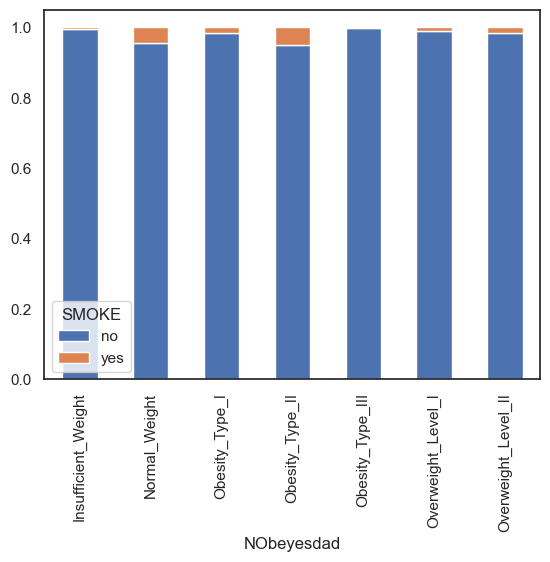

In [26]:
df.groupby('NObeyesdad')['SMOKE'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)


Although only ~2% of the population smokes, nearly 70% of smokers fall into high-risk obesity categories, indicating a disproportionate association

In [27]:
##We can still interpret for person who are all smokers but losing weight 

lower_weight_category = ['Insufficient_Weight']

smokers_in_lower_obesity = df_smokers[df_smokers['NObeyesdad'].isin(lower_weight_category)]



percentage_of_lower_obesity_who_smoke = len(smokers_in_lower_obesity.index) / len(df_smokers.index)* 100
print(f" The Percentage of smokers who are less weight is: {percentage_of_lower_obesity_who_smoke}")

 The Percentage of smokers who are less weight is: 2.272727272727273


In [28]:
df_cat.groupby('Gender').apply(lambda x : (x['MTRANS'] == 'Public_Transportation').mean()*100)

Gender
Female    81.835749
Male      67.585551
dtype: float64

In [29]:
df_cat.groupby(['Gender','family_history_with_overweight']).apply(lambda x : (x['SMOKE']=='yes').count())

Gender  family_history_with_overweight
Female  no                                226
        yes                               809
Male    no                                139
        yes                               913
dtype: int64

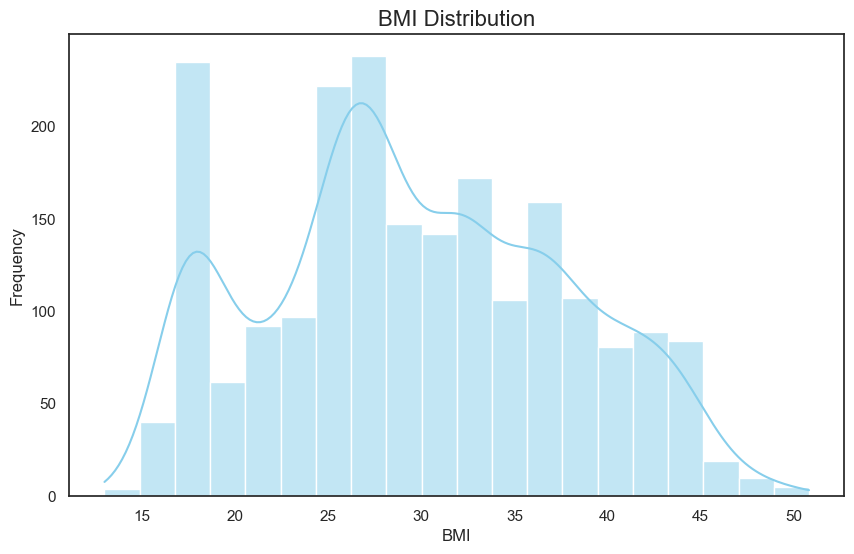

count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64


In [30]:
##checking BMI 

df['BMI'] = df['Weight'] / (df['Height'] **2)

def bmi_category(BMI):
    if BMI < 18.5:
        return 'underweight'
    elif 18.5 <= BMI < 25:
        return 'Normal'
    elif 25 <= BMI < 30:
        return 'Overweight'
    else:
        return 'obese'
df['BMI_CATEGORY'] = df['BMI'].apply(bmi_category)

plt.figure(figsize =(10,6))
sns.histplot(df['BMI'], kde = True, bins = 20, color= 'skyblue')
plt.title('BMI Distribution', fontsize = 16)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

print(df['BMI'].describe())

In [31]:
##show dataframe
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI,BMI_CATEGORY
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight,24.386526,Normal
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,24.238227,Normal
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight,23.765432,Normal
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I,26.851852,Overweight
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,44.901475,obese
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,43.741923,obese
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,43.543817,obese
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,44.071535,obese


In [32]:
## i have added BMI in the Dataframe to do a bivariate analysis of BMI categories vs obesity levels in more precise range

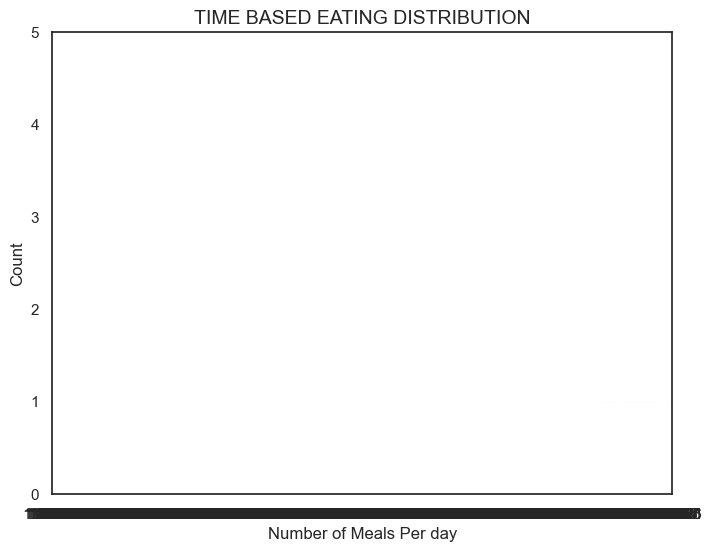

In [33]:
##Time based eating patterns.
plt.figure(figsize =(8,6))
sns.countplot(x='NCP', data=df, palette='Blues')
plt.ylim(0,5)
plt.title('TIME BASED EATING DISTRIBUTION', fontsize =14)
plt.xlabel('Number of Meals Per day')
plt.ylabel('Count') 
plt.show()

In [35]:
### Transport Lifestyle

df['MTRANS'].unique()

array(['Public_Transportation', 'Walking', 'Automobile', 'Motorbike',
       'Bike'], dtype=object)

In [40]:
from scipy.stats import ttest_ind, chi2_contingency

Counts of commute Type:
Active       1636
Sedentary     475
Name: Commute_Type, dtype: int64

Mean BMI by Commute Type:
Commute_Type
Active       29.889011
Sedentary    29.049711
Name: BMI, dtype: float64

Obesity Prevalence (%):
Commute_Type
Active       46.638142
Sedentary    44.421053
Name: obese, dtype: float64


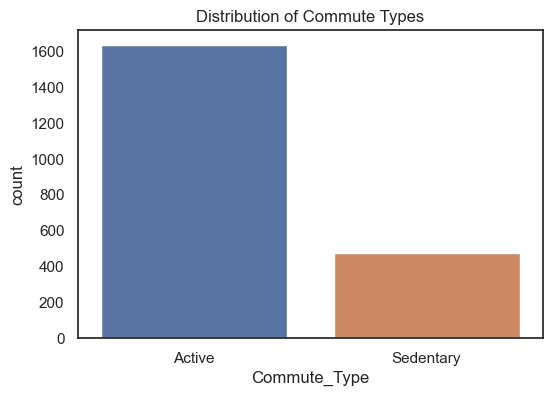

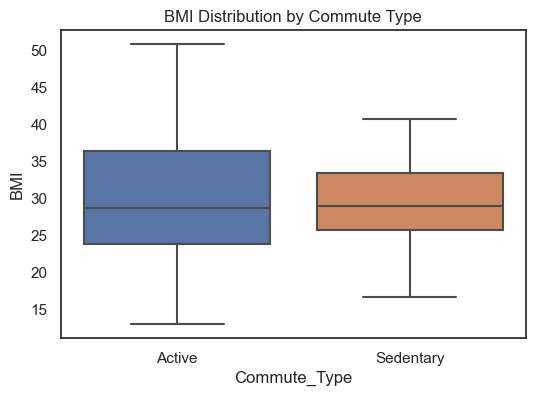

<Figure size 600x400 with 0 Axes>

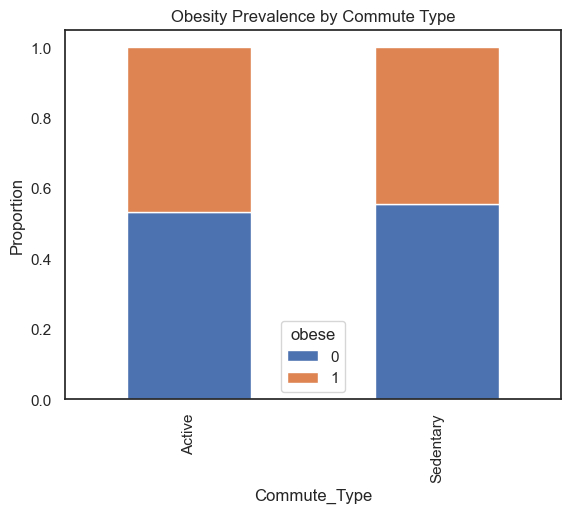


T-test BMI Active vs Sedentary:
Ttest_indResult(statistic=2.0114982410249413, pvalue=0.04439984887462227)

Chi-square test Commute vs Obesity:
Chi2=0.64, p=0.4231, dof=1


In [42]:
# 1. Define commute type
def commute(x):
    if x in ["Public_Transportation", "Walking"]:
        return "Active"
    elif x in ["Automobile","Motorbike","Bike"]:
        return "Sedentary"
    else:
        return "Other"

df["Commute_Type"] = df["MTRANS"].apply(commute)

# 2. Counts and descriptive stats
print("Counts of commute Type:")
print(df["Commute_Type"].value_counts())

print("\nMean BMI by Commute Type:")
print(df.groupby("Commute_Type")["BMI"].mean())

# 3. Obesity prevalence
df["obese"] = (df["BMI"] >= 30).astype(int)
print("\nObesity Prevalence (%):")
print(df.groupby("Commute_Type")["obese"].mean()*100)

# 4. Visualizations
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Commute_Type")
plt.title("Distribution of Commute Types")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Commute_Type", y="BMI")
plt.title("BMI Distribution by Commute Type")
plt.show()

plt.figure(figsize=(6,4))
crosstab = pd.crosstab(df["Commute_Type"], df["obese"])
crosstab.div(crosstab.sum(1), axis=0).plot(kind="bar", stacked=True)
plt.title("Obesity Prevalence by Commute Type")
plt.ylabel("Proportion")
plt.show()

# 5. Statistical tests
active_bmi = df.loc[df["Commute_Type"]=="Active", "BMI"]
sedentary_bmi = df.loc[df["Commute_Type"]=="Sedentary", "BMI"]

print("\nT-test BMI Active vs Sedentary:")
print(ttest_ind(active_bmi, sedentary_bmi, nan_policy='omit'))

contingency = pd.crosstab(df["Commute_Type"], df["obese"])
chi2, p, dof, ex = chi2_contingency(contingency)
print("\nChi-square test Commute vs Obesity:")
print(f"Chi2={chi2:.2f}, p={p:.4f}, dof={dof}")


# Observations

Dietary Patterns:

Individuals with high consumption of fast food, sugary drinks, and processed snacks tend to have higher BMI.

Frequent consumption of fruits, vegetables, and home-cooked meals is associated with lower BMI.

Physical Condition / Activity:

Sedentary lifestyles, such as long hours of sitting or minimal exercise, correlate with higher obesity prevalence.

Regular physical activity, walking, or active commuting is associated with lower obesity rates.

Combined Effect:

Participants with unhealthy eating habits and low physical activity are at the highest risk of obesity.

Conversely, even if diet is not optimal, higher physical activity can partially offset obesity risk.

Demographic Trends (if analyzed):

Age, gender, or socioeconomic factors may influence obesity patterns and interact with lifestyle habits.

# Conclusions

Obesity is strongly influenced by both eating habits and physical activity levels.

Promoting healthy diets and active lifestyles is critical in reducing obesity risk.

Predictive analysis using lifestyle and physical condition data can help identify high-risk individuals for targeted interventions.

Public health strategies should integrate nutritional education and encouragement of active commuting or exercise to mitigate obesity prevalence.